# Intensidad y dano civil en conflictos recientes

        **Pregunta guia:** ¿como ha cambiado la intensidad de los conflictos armados recientes desde 2022, que paises concentran la mayor letalidad y que tanto predice la frecuencia mensual de eventos el numero de muertes estimadas?

        Este notebook esta pensado como entrega academica: cada bloque explica que se hace, por que se hace y que decision analitica queda documentada. La base cruda se toma de UCDP, se limpia en Python/Jupyter y se transforma en datos listos para graficas, storytelling y una app de Streamlit.

## 1. Contexto y objetivo

        UCDP registra eventos de violencia organizada con fecha, lugar, actores y estimaciones de muertes. Para el trabajo nos interesa demostrar el ciclo completo visto en clase: inspeccion inicial, limpieza, filtros, `groupby`, EDA univariado, comparaciones bivariadas, visualizacion, storytelling y regresion lineal.

        **Objetivo analitico:** transformar una base grande y parcialmente sucia en una explicacion clara sobre intensidad, dano civil e incertidumbre en conflictos actuales.

In [1]:
from pathlib import Path
import sys
import site

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))
site.addsitedir(str(PROJECT_ROOT.parent / ".pydeps"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from ucdp_pipeline import (
    ensure_data_files,
    load_raw_events,
    initial_quality_report,
    clean_events,
    build_monthly_panel,
    build_global_monthly,
    linear_regression_summary,
    export_processed,
)

DATA_DIR = PROJECT_ROOT / "data"
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", palette="Set2")

## 2. Carga de datos

        El proyecto integra tres archivos oficiales:

        - GED 25.1: eventos globales entre 1989 y 2024.
        - Candidate GED 2025: eventos candidatos acumulados para 2025.
        - Candidate GED 26.0.3: eventos candidatos disponibles hasta marzo de 2026.

        Si los archivos no estan descargados, la siguiente celda puede descargarlos desde UCDP. En clase es recomendable ejecutar con internet antes de la presentacion y luego trabajar con los archivos locales.

In [2]:
missing = ensure_data_files(DATA_DIR, download=False)
if missing:
    print("Faltan archivos raw. Para descargarlos automaticamente ejecute:")
    print("ensure_data_files(DATA_DIR, download=True)")
    for path in missing:
        print("-", path)
else:
    print("Archivos raw disponibles.")

Archivos raw disponibles.


In [ ]:
raw = load_raw_events(DATA_DIR)
print(f"Filas crudas: {raw.shape[0]:,}")
print(f"Columnas crudas: {raw.shape[1]:,}")
display(raw.head())

## 3. Diagnostico inicial de calidad

        Antes de limpiar, se aplica el ritual de inspeccion de clase: dimensiones, tipos, nulos, duplicados y valores especiales. Este paso evita limpiar a ciegas.

In [4]:
try:
    raw
except NameError:
    raw = load_raw_events(DATA_DIR)
    print('raw no estaba definido. Cargando raw desde DATA_DIR...')

print("Rango de anos:", int(raw["year"].min()), "-", int(raw["year"].max()))
print("Duplicados por id:", raw.duplicated("id").sum())
display(raw.dtypes.to_frame("tipo").head(20))

quality_raw = initial_quality_report(raw)
display(quality_raw.head(15))


Rango de anos: 1989 - 2026
Duplicados por id: 0


,tipo
id,int64
relid,str
year,int64
active_year,bool
code_status,str
type_of_violence,int64
conflict_dset_id,object
conflict_new_id,int64
conflict_name,str
dyad_dset_id,object


,tipo,nulos,pct_nulo,unicos,ejemplo
id,int64,0,0.0,387705,244657
relid,str,0,0.0,387705,IRQ-2017-1-524-322
year,int64,0,0.0,37,2017
active_year,bool,0,0.0,2,True
code_status,str,0,0.0,8,Clear
type_of_violence,int64,0,0.0,3,1
conflict_dset_id,object,197,0.1,1667,259
conflict_new_id,int64,0,0.0,1618,259
conflict_name,str,0,0.0,1627,Iraq: Government
dyad_dset_id,object,2,0.0,1952,524


In [5]:
sentinel_sources = (pd.to_numeric(raw["number_of_sources"], errors="coerce") == -1).sum()
print("Registros con number_of_sources = -1:", int(sentinel_sources))

fatality_cols = ["best", "high", "low", "deaths_civilians"]
display(raw[fatality_cols].describe().T)

Registros con number_of_sources = -1: 97913


,count,mean,std,min,25%,50%,75%,max
best,387705.0,10.253203,347.093228,0.0,1.0,2.0,4.0,121848.0
high,387705.0,15.100662,425.957351,0.0,1.0,2.0,5.0,121848.0
low,387705.0,8.543039,313.169641,0.0,1.0,2.0,4.0,121848.0
deaths_civilians,387705.0,3.811186,178.004812,0.0,0.0,0.0,1.0,40000.0


## 4. Limpieza y transformacion

        Decisiones aplicadas:

        - Convertir fechas a tipo datetime.
        - Convertir variables numericas con `pd.to_numeric`.
        - Eliminar duplicados por `id`.
        - Tratar `number_of_sources = -1` como nulo porque no es un conteo comparable.
        - Crear etiquetas legibles para tipos de violencia y precision.
        - Crear variables nuevas: mes, duracion, incertidumbre y proporcion de muertes civiles.
        - Validar coordenadas basicas.

In [6]:
clean = clean_events(raw)
print(f"Filas limpias: {clean.shape[0]:,}")
print("Duplicados removidos:", clean.attrs.get("duplicates_removed", 0))
display(clean.head())

Filas limpias: 387,705
Duplicados removidos: 0


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,dyad_new_id,dyad_name,side_a_dset_id,side_a_new_id,side_a,side_b_dset_id,side_b_new_id,side_b,number_of_sources,source_article,source_office,source_date,source_headline,source_original,where_prec,where_coordinates,where_description,adm_1,adm_2,latitude,longitude,geom_wkt,priogrid_gid,country,country_id,region,event_clarity,date_prec,date_start,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob,_source_file,month,event_month,uncertainty,civil_ratio,violence_label
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,3.0,"""Agence France Presse,2017-08-01,At least 20 k...",Agence France Presse;Agence France Presse;Pajh...,2017-08-01;2017-08-01;2017-07-31,At least 20 killed in Shiite mosque attack in ...,"IS, interior ministry, security source",1,Kabul city,Iraqi embassy in Kabul,Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,1,2017-07-31,2017-07-31,0,4,0,2,6,6,6,645,NaN,ged251,7,2017-07-01,0,0.000000,State-based
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,15.0,"""BBC News,2021-08-26,Explosion at Kabul airpor...",BBC News;ShamshadNews on Twitter;Xinhua News A...,2021-08-26;2021-08-26;2021-08-30;2021-08-27;20...,Explosion at Kabul airport;At least 11 people ...,US officials; Taliban spokesman Zabihullah Muj...,1,Kabul international airport,Kabul airport (Abbey gate entrance),Kabul province,Kabul district,34.564444,69.217222,POINT (69.2172222 34.5644444),179779,Afghanistan,700,Asia,1,1,2021-08-26,2021-08-26,13,1,141,28,183,184,171,645,NaN,ged251,8,2021-08-01,13,0.770492,State-based
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,5.0,"""Khaama Press,2021-08-28,First US airstrike hi...",Khaama Press;Reuters News;Agence France Presse...,2021-08-28;2021-08-28;2021-08-28;2021-08-28;20...,First US airstrike hits ISIS-K fighter after T...,US central command spokesperson Captain Bill U...,1,Jalalabad town,Police District 7 of Jalalabad city,Nangarhar province,Jalalabad district,34.428844,70.455750,POINT (70.45575 34.428844),179061,Afghanistan,700,Asia,1,1,2021-08-28,2021-08-28,0,2,0,0,2,3,0,645,NaN,ged251,8,2021-08-01,3,0.000000,State-based
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,524,Government of Iraq - IS,116,116,Government of Iraq,234,234,IS,8.0,"""CNN,2021-08-29,Nine family members, including...",CNN;Reuters News;Associated Press Newswires;BB...,2021-08-29;2021-08-29;2021-08-30;2021-08-31;20...,"Nine family members, including children, kille...",relative; US Central Command; witnesses; Afgha...,1,Kabul city,Kabul city (district 15),Kabul province,Kabul district,34.531094,69.162796,POINT (69.162796 34.531094),179779,Afghanistan,700,Asia,1,1,2021-08-29,2021-08-29,0,0,10,0,10,10,9,645,NaN,ged251,8,2021-08-01,1,1.000000,State-based
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,724,Government of Afghanistan - Jam'iyyat-i Islami...,130,130,Government of Afghanistan,292,292,Jam'iyyat-i Islami-yi Afghanistan,NaN,"The Times 13 Jan 1989 ""Missiles and tea breaks...",NaN,NaN,NaN,Rebel source,4,Nangarhar province,Nangarhar province,Nangarhar province,NaN,34.333330,70.416670,POINT (70.41667 34.33333),179061,Afghanistan,700,Asia,1,3,1989-01-07,1989-01-13,6,0,0,0,6,6,6,700,NaN,ged251,1,1989-01-01,0,0.000000,State-based


In [7]:
quality_clean = initial_quality_report(clean)
display(quality_clean.head(15))

comparison = pd.DataFrame({
    "metrica": ["filas", "duplicados_id", "columnas"],
    "antes": [len(raw), raw.duplicated("id").sum(), raw.shape[1]],
    "despues": [len(clean), clean.duplicated("id").sum(), clean.shape[1]],
})
display(comparison)

,tipo,nulos,pct_nulo,unicos,ejemplo
id,int64,0,0.0,387705,244657
relid,str,0,0.0,387705,IRQ-2017-1-524-322
year,int32,0,0.0,37,2017
active_year,bool,0,0.0,2,True
code_status,str,0,0.0,8,Clear
type_of_violence,int64,0,0.0,3,1
conflict_dset_id,object,197,0.1,1667,259
conflict_new_id,int64,0,0.0,1618,259
conflict_name,str,0,0.0,1627,Iraq: Government
dyad_dset_id,object,2,0.0,1952,524


,metrica,antes,despues
0,filas,387705,387705
1,duplicados_id,0,0
2,columnas,50,55


## 5. Foco reciente y preguntas de analisis

        Para contar una historia relacionada con guerras actuales, el analisis descriptivo se concentra en 2022-2026. Esto incluye Rusia-Ucrania, Israel-Palestina, Sudan, Etiopia y otros conflictos con alta letalidad reciente.

In [8]:
recent = clean[clean["year"] >= 2022].copy()
print(f"Eventos recientes desde 2022: {len(recent):,}")
print(f"Muertes estimadas recientes: {recent['best'].sum():,.0f}")
print(f"Muertes civiles recientes: {recent['deaths_civilians'].sum():,.0f}")

Eventos recientes desde 2022: 77,863
Muertes estimadas recientes: 649,848
Muertes civiles recientes: 108,503


In [9]:
by_year = recent.groupby("year").agg(
    eventos=("id", "count"),
    muertes=("best", "sum"),
    civiles=("deaths_civilians", "sum"),
)
by_year["proporcion_civil"] = by_year["civiles"] / by_year["muertes"]
display(by_year)

,eventos,muertes,civiles,proporcion_civil
year,,,,
2022,20774,309636,34799,0.112387
2023,26486,161237,35235,0.218529
2024,28816,160900,34948,0.217203
2026,1787,18075,3521,0.194799


## 6. Analisis univariado

        La variable `best` mide la mejor estimacion de muertes por evento. Su distribucion suele ser asimetrica: muchos eventos tienen pocas muertes y pocos eventos concentran una letalidad extrema. Por eso conviene mirar media, mediana, IQR y outliers.

In [10]:
x = recent["best"].dropna()
q1, q3 = x.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outliers = (x > upper).sum()

summary_best = pd.DataFrame({
    "media": [x.mean()],
    "mediana": [x.median()],
    "desviacion": [x.std()],
    "iqr": [iqr],
    "limite_outlier_superior": [upper],
    "outliers": [outliers],
    "porcentaje_outliers": [outliers / len(x) * 100],
})
display(summary_best.round(2))

,media,mediana,desviacion,iqr,limite_outlier_superior,outliers,porcentaje_outliers
0,8.35,1.0,456.08,2.0,6.0,8507,10.93


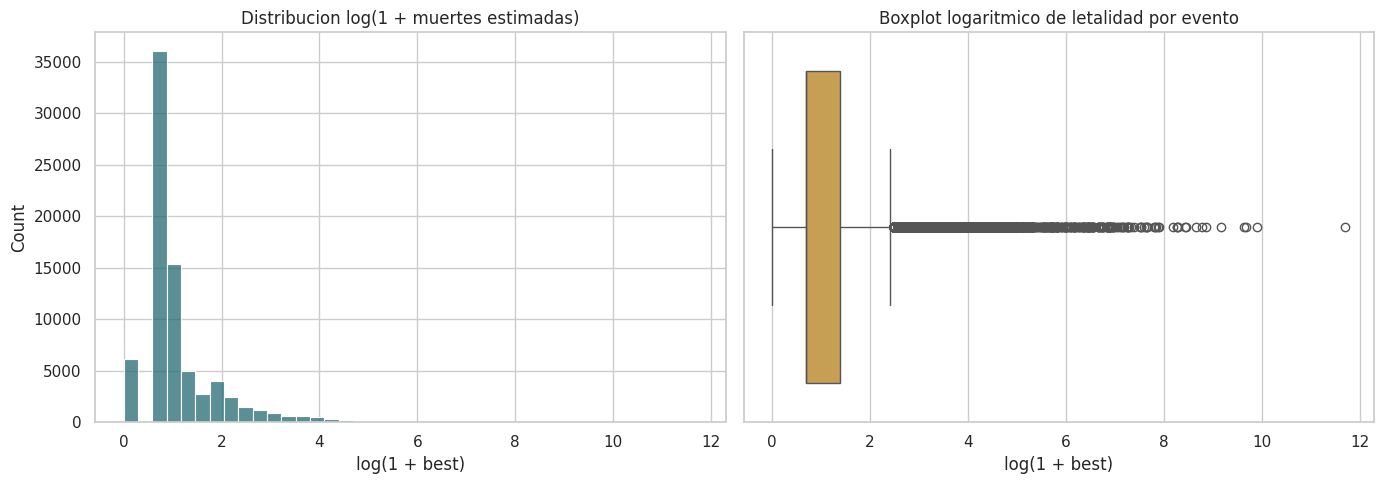

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.log1p(recent["best"]), bins=40, ax=axes[0], color="#246A73")
axes[0].set_title("Distribucion log(1 + muertes estimadas)")
axes[0].set_xlabel("log(1 + best)")

sns.boxplot(x=np.log1p(recent["best"]), ax=axes[1], color="#D9A441")
axes[1].set_title("Boxplot logaritmico de letalidad por evento")
axes[1].set_xlabel("log(1 + best)")
plt.tight_layout()
plt.show()

## 7. Agrupaciones: paises, conflictos y tipos de violencia

        Aqui reutilizamos `groupby` para pasar de registros individuales a hallazgos comparables. Esta parte construye los rankings que luego alimentan el storytelling.

In [12]:
top_countries = (
    recent.groupby("country", dropna=False)
    .agg(eventos=("id", "count"), muertes=("best", "sum"), civiles=("deaths_civilians", "sum"))
    .sort_values("muertes", ascending=False)
    .head(15)
)
top_countries["proporcion_civil"] = top_countries["civiles"] / top_countries["muertes"]
display(top_countries)

,eventos,muertes,civiles,proporcion_civil
country,,,,
Ukraine,28241,243896,24382,0.099969
Ethiopia,2419,172210,4521,0.026253
Israel,4398,49125,28320,0.576489
Mexico,7820,34737,459,0.013214
Sudan,1258,17423,7981,0.458073
DR Congo (Zaire),2835,15460,11124,0.719534
Burkina Faso,1203,13206,4715,0.357035
Nigeria,1731,10877,1496,0.137538
Somalia,785,9999,802,0.080208


In [13]:
top_conflicts = (
    recent.groupby("conflict_name", dropna=False)
    .agg(eventos=("id", "count"), muertes=("best", "sum"), civiles=("deaths_civilians", "sum"))
    .sort_values("muertes", ascending=False)
    .head(15)
)
top_conflicts["muertes_por_evento"] = top_conflicts["muertes"] / top_conflicts["eventos"]
display(top_conflicts)

,eventos,muertes,civiles,muertes_por_evento
conflict_name,,,,
Russia - Ukraine,28764,250157,23284,8.696878
Ethiopia: Government,355,162463,529,457.642254
Israel: Palestine,4309,48364,27543,11.223950
Jalisco Cartel New Generation - Sinaloa Cartel,1893,11284,39,5.960909
Sudan: Government,814,11072,3766,13.601966
IS - Civilians,1537,9914,9833,6.450228
Somalia: Government,694,9203,588,13.260807
Burkina Faso: Government,763,7731,587,10.132372
Jalisco Cartel New Generation - Santa Rosa de Lima Cartel,1654,6802,30,4.112455


In [14]:
fig = px.bar(
    top_countries.reset_index(),
    x="muertes",
    y="country",
    color="proporcion_civil",
    orientation="h",
    title="Paises con mayor letalidad estimada desde 2022",
    labels={"muertes": "Muertes estimadas", "country": "Pais", "proporcion_civil": "Proporcion civil"},
    color_continuous_scale="Tealrose",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

## 8. Panel mensual para visualizacion y regresion

        Se agregan eventos por mes, pais, conflicto y tipo de violencia. Este panel permite crear graficas temporales y ajustar una regresion lineal mensual.

In [15]:
monthly_panel = build_monthly_panel(clean, min_year=2022)
global_monthly = build_global_monthly(monthly_panel)
display(monthly_panel.head())
display(global_monthly.head())

,event_month,conflict_name,country,type_of_violence,events,fatalities_best,civilian_fatalities,uncertainty_total,high_fatalities,low_fatalities
0,2022-01-01,AFP-Gutabara - FABB,DR Congo (Zaire),2,1,1,0,0,1,1
111,2022-01-01,Iraq: Government,Iraq,1,10,49,0,5,53,48
112,2022-01-01,Israel: Palestine,Israel,1,2,3,0,0,3,3
113,2022-01-01,JAS - Civilians,Cameroon,3,1,2,2,0,2,2
114,2022-01-01,JNIM - Civilians,Burkina Faso,3,1,9,9,0,9,9


,event_month,events,fatalities_best,civilian_fatalities,uncertainty_total,high_fatalities,low_fatalities
0,2022-01-01,1198,14322,1458,13512,17850,4338
1,2022-02-01,1302,22158,12276,23591,37252,13661
2,2022-03-01,2185,32149,5824,57435,83720,26285
3,2022-04-01,1703,8860,2082,5087,12690,7603
4,2022-05-01,1737,8145,1867,6271,13358,7087


In [16]:
fig = px.line(
    global_monthly,
    x="event_month",
    y=["fatalities_best", "civilian_fatalities"],
    title="Letalidad mensual global en conflictos recientes",
    labels={"value": "Muertes", "event_month": "Mes", "variable": "Serie"},
)
fig.show()

## 9. Regresion lineal

        La regresion evalua una pregunta sencilla: cuando sube el numero mensual de eventos, ¿suben tambien las muertes estimadas? El modelo no pretende explicar toda la complejidad politica o militar; sirve para cuantificar una relacion inicial y discutir sus limites.

In [17]:
regression_metrics = linear_regression_summary(global_monthly, target="fatalities_best")
regression_metrics

{'slope': 4.1515,
 'intercept': 8374.3727,
 'r2': 0.0103,
 'rmse': 25047.07,
 'months': 39}

In [18]:
x = global_monthly["events"].to_numpy(dtype=float)
y_hat = regression_metrics["intercept"] + regression_metrics["slope"] * x

fig = px.scatter(
    global_monthly,
    x="events",
    y="fatalities_best",
    hover_data=["event_month"],
    title="Regresion lineal: eventos mensuales vs muertes estimadas",
    labels={"events": "Eventos por mes", "fatalities_best": "Muertes estimadas por mes"},
)
fig.add_scatter(x=global_monthly["events"], y=y_hat, mode="lines", name="Regresion lineal")
fig.show()

print(f"Pendiente: {regression_metrics['slope']:.2f}")
print(f"R2: {regression_metrics['r2']:.3f}")
print(f"RMSE: {regression_metrics['rmse']:.0f}")

Pendiente: 4.15
R2: 0.010
RMSE: 25047


## 10. Casos especificos de conflicto

        Para que el trabajo no se quede en una mirada global, se seleccionan cuatro conflictos con alto peso reciente en la base: Rusia-Ucrania, Etiopia, Israel-Palestina y Sudan. La comparacion permite mostrar que cada conflicto tiene una dinamica distinta: continuidad, picos de escalamiento, dano civil e incertidumbre.

In [19]:
case_conflicts = ["Russia - Ukraine", "Ethiopia: Government", "Israel: Palestine", "Sudan: Government"]
case_labels = {
    "Russia - Ukraine": "Rusia-Ucrania",
    "Ethiopia: Government": "Etiopia",
    "Israel: Palestine": "Israel-Palestina",
    "Sudan: Government": "Sudan",
}

cases = monthly_panel[monthly_panel["conflict_name"].isin(case_conflicts)].copy()
cases["caso"] = cases["conflict_name"].map(case_labels)

case_summary = (
    cases.groupby(["conflict_name", "caso"], as_index=False)
    .agg(
        eventos=("events", "sum"),
        muertes=("fatalities_best", "sum"),
        civiles=("civilian_fatalities", "sum"),
        incertidumbre=("uncertainty_total", "sum"),
    )
    .sort_values("muertes", ascending=False)
)
case_summary["muertes_por_evento"] = case_summary["muertes"] / case_summary["eventos"]
case_summary["proporcion_civil"] = case_summary["civiles"] / case_summary["muertes"]
display(case_summary)

,conflict_name,caso,eventos,muertes,civiles,incertidumbre,muertes_por_evento,proporcion_civil
2,Russia - Ukraine,Rusia-Ucrania,28764,250157,23284,226027,8.696878,0.093078
0,Ethiopia: Government,Etiopia,355,162463,529,1736,457.642254,0.003256
1,Israel: Palestine,Israel-Palestina,4309,48364,27543,320,11.223950,0.569494
3,Sudan: Government,Sudan,814,11072,3766,1227,13.601966,0.340137


In [20]:
case_monthly = (
    cases.groupby(["event_month", "caso"], as_index=False)
    .agg(eventos=("events", "sum"), muertes=("fatalities_best", "sum"), civiles=("civilian_fatalities", "sum"))
    .sort_values("event_month")
)

fig = px.line(
    case_monthly,
    x="event_month",
    y="muertes",
    color="caso",
    title="Trayectorias mensuales de los conflictos seleccionados",
    labels={"event_month": "Mes", "muertes": "Muertes estimadas", "caso": "Caso"},
)
fig.show()

In [21]:
fig = px.scatter(
    case_summary,
    x="eventos",
    y="muertes",
    size="civiles",
    color="caso",
    text="caso",
    title="Frecuencia, letalidad y dano civil por conflicto",
    labels={"eventos": "Eventos", "muertes": "Muertes estimadas", "civiles": "Muertes civiles"},
)
fig.update_traces(textposition="top center")
fig.show()

## 11. Regresion por caso e interpretacion academica

        El modelo global tiene un R2 bajo, lo que no invalida el proyecto; al contrario, se convierte en un hallazgo: la frecuencia de eventos no explica de forma suficiente la letalidad. Para profundizar, se ajusta la misma regresion por conflicto y se compara que tanto cambia el poder explicativo segun el caso.

In [22]:
case_regression_rows = []
for conflict in case_conflicts:
    monthly_case = (
        monthly_panel[monthly_panel["conflict_name"] == conflict]
        .groupby("event_month", as_index=False)
        .agg(events=("events", "sum"), fatalities_best=("fatalities_best", "sum"))
    )
    metrics = linear_regression_summary(monthly_case, target="fatalities_best")
    case_regression_rows.append({
        "caso": case_labels[conflict],
        "meses": metrics["months"],
        "pendiente": metrics["slope"],
        "r2": metrics["r2"],
        "rmse": metrics["rmse"],
    })

case_regression = pd.DataFrame(case_regression_rows).sort_values("r2", ascending=False)
display(case_regression)

,caso,meses,pendiente,r2,rmse
2,Israel-Palestina,37,13.6923,0.5898,1561.99
3,Sudan,26,8.3878,0.2466,260.35
0,Rusia-Ucrania,36,-1.6191,0.0085,4885.72
1,Etiopia,12,7.4152,0.0000,43977.36


**Lectura:** si un caso tiene mayor R2, significa que dentro de ese conflicto la frecuencia mensual de eventos se parece mas al comportamiento de la letalidad. Si el R2 es bajo, la explicacion debe buscarse en la intensidad de eventos especificos, cambios de estrategia, ataques masivos, errores de medicion o incertidumbre de fuente.

        Esta discusion es importante para la exposicion porque muestra pensamiento critico: no se fuerza el modelo para que "salga bonito"; se interpreta lo que el modelo realmente dice.

## 12. Interpretacion para storytelling

        Lectura sugerida:

        1. La base reciente supera cien mil eventos, lo que justifica un flujo de limpieza y agregacion.
        2. La letalidad se concentra en pocos paises y conflictos, especialmente Rusia-Ucrania, Etiopia, Israel-Palestina y Sudan.
        3. La regresion permite demostrar un limite analitico: frecuencia de eventos e intensidad humana no son equivalentes.
        4. El valor academico del trabajo esta en pasar de una base grande y dificil a una conclusion prudente y defendible.

In [23]:
outputs = export_processed(DATA_DIR, clean, min_year=2022)
for name, path in outputs.items():
    print(name, "->", path)

events_recent -> /workspaces/Mineria_Datos/proyecto_conflicto_ucdp_COMPLETO/proyecto_conflicto_ucdp/data/processed/events_recent.csv
monthly_panel -> /workspaces/Mineria_Datos/proyecto_conflicto_ucdp_COMPLETO/proyecto_conflicto_ucdp/data/processed/monthly_panel.csv
global_monthly -> /workspaces/Mineria_Datos/proyecto_conflicto_ucdp_COMPLETO/proyecto_conflicto_ucdp/data/processed/global_monthly.csv


## 13. Conclusiones y limites

        **Conclusion principal:** contar eventos no basta para entender una guerra. La frecuencia mensual ayuda, pero la intensidad por evento, el dano civil, la incertidumbre de las estimaciones y la precision geografica cambian la historia.

        **Limitaciones:** UCDP registra eventos letales reportados; los datos Candidate son preliminares; una regresion lineal simple no captura causalidad ni cambios estrategicos en cada conflicto.

        **Siguiente paso:** usar la app de Streamlit para que el publico filtre paises, anos y tipos de violencia durante la presentacion.